# FHI-aims Molecular Dynamics Analysis and Thermodynamic Diagnostics

This script performs a comprehensive analysis of Molecular Dynamics (MD) simulations carried out with FHI-aims by extracting thermodynamic and energetic properties directly from the output file.

Pasos de MD leídos: 20000


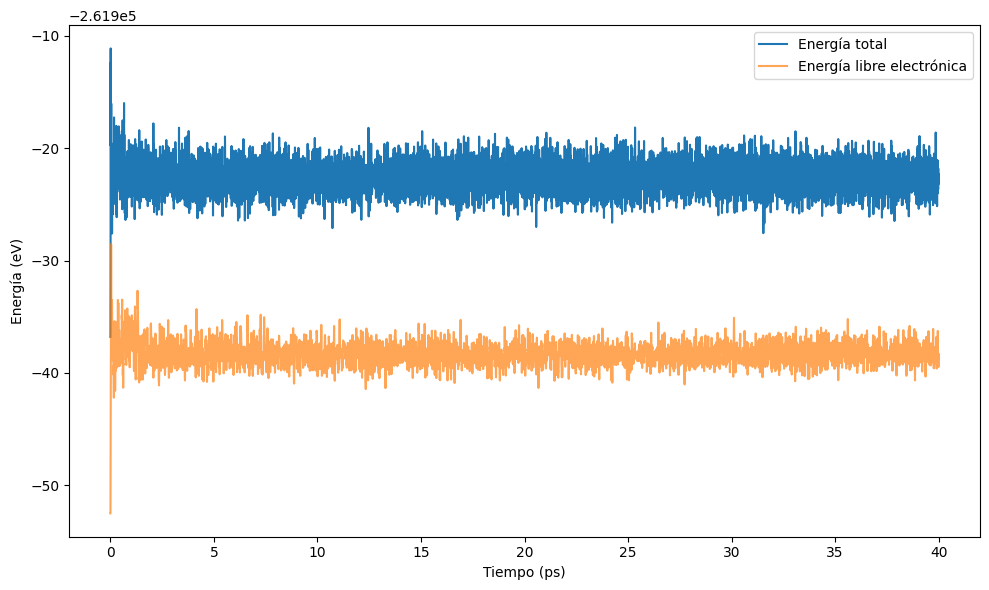

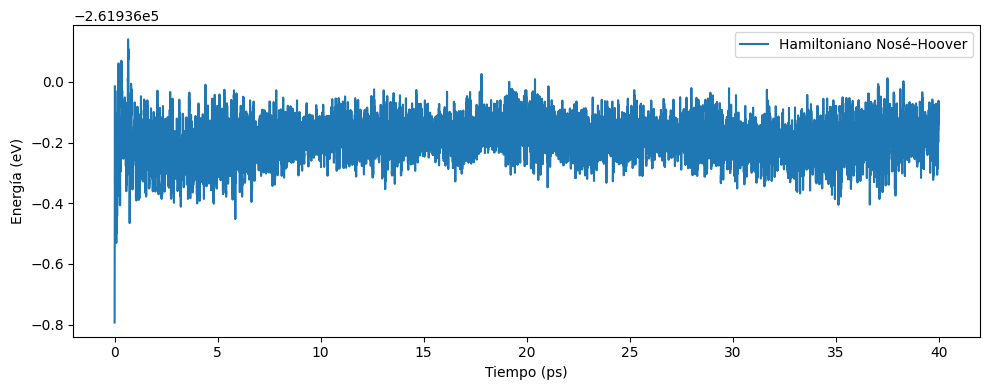

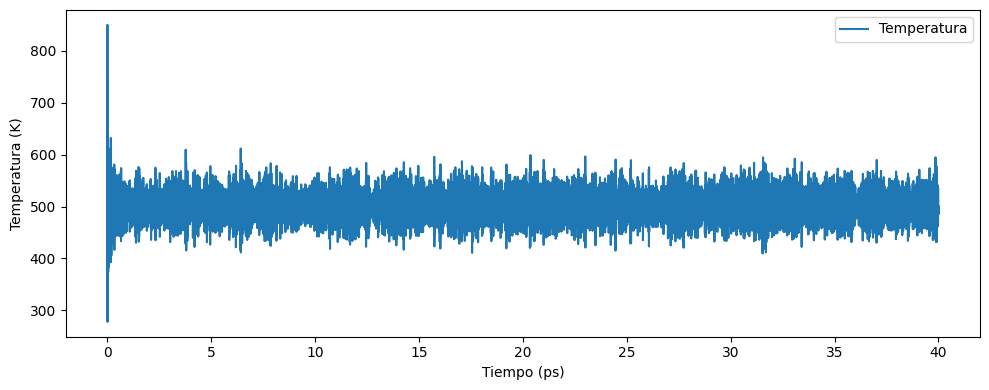

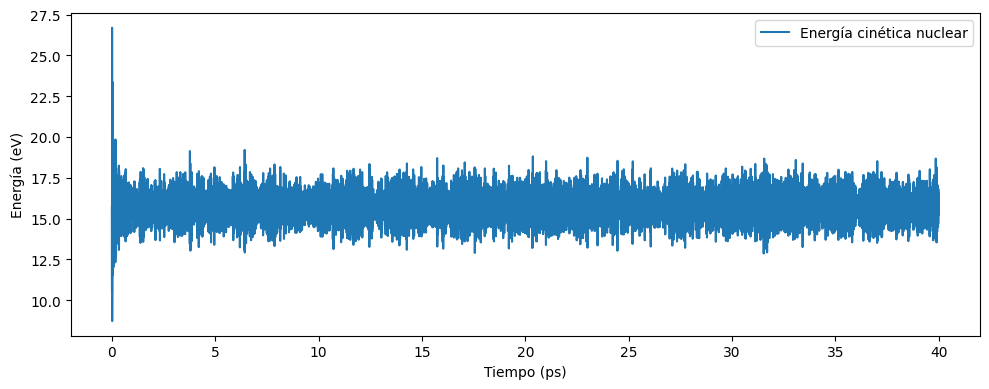

In [3]:
import re
import matplotlib.pyplot as plt

# =========================
# Archivo de entrada
# =========================
filename = "salida.out"

# =========================
# Contenedores
# =========================
step = []
time_ps = []
temp = []
ekin = []
efree = []
etot = []
nose = []

# =========================
# Expresiones regulares
# =========================
re_step  = re.compile(r"Time step number\s*:\s*(\d+)")
re_time  = re.compile(r"Simulation time\s*:\s*([Ee0-9\.\+\-]+)\s*ps")
re_temp  = re.compile(r"Temperature \(nuclei\)\s*:\s*([Ee0-9\.\+\-]+)\s*K")
re_ekin  = re.compile(r"Nuclear kinetic energy\s*:\s*([Ee0-9\.\+\-]+)\s*eV")
re_efree = re.compile(r"Electronic free energy\s*:\s*([Ee0-9\.\+\-]+)\s*eV")
re_etot  = re.compile(r"Total energy \(el\.\+nuc\.\)\s*:\s*([Ee0-9\.\+\-]+)\s*eV")
re_nose  = re.compile(r"Nose-Hoover Hamiltonian\s*:\s*([Ee0-9\.\+\-]+)\s*eV")

# =========================
# Lectura del archivo
# =========================
with open(filename, "r") as f:
    for line in f:

        if m := re_step.search(line):
            step.append(int(m.group(1)))

        elif m := re_time.search(line):
            time_ps.append(float(m.group(1)))

        elif m := re_temp.search(line):
            temp.append(float(m.group(1)))

        elif m := re_ekin.search(line):
            ekin.append(float(m.group(1)))

        elif m := re_efree.search(line):
            efree.append(float(m.group(1)))

        elif m := re_etot.search(line):
            etot.append(float(m.group(1)))

        elif m := re_nose.search(line):
            nose.append(float(m.group(1)))

# =========================
# Comprobación rápida
# =========================
n = min(len(time_ps), len(etot))
print(f"Pasos de MD leídos: {n}")

time_ps = time_ps[:n]
temp    = temp[:n]
ekin    = ekin[:n]
efree   = efree[:n]
etot    = etot[:n]
nose    = nose[:n]

# =========================
# Gráficas
# =========================
plt.figure(figsize=(10, 6))
plt.plot(time_ps, etot, label="Energía total")
plt.plot(time_ps, efree, label="Energía libre electrónica", alpha=0.7)
plt.xlabel("Tiempo (ps)")
plt.ylabel("Energía (eV)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_ps, nose, label="Hamiltoniano Nosé–Hoover")
plt.xlabel("Tiempo (ps)")
plt.ylabel("Energía (eV)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_ps, temp, label="Temperatura")
plt.xlabel("Tiempo (ps)")
plt.ylabel("Temperatura (K)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_ps, ekin, label="Energía cinética nuclear")
plt.xlabel("Tiempo (ps)")
plt.ylabel("Energía (eV)")
plt.legend()
plt.tight_layout()
plt.show()

Pasos de MD analizados: 20000

--- PROMEDIOS ---
Temperatura promedio        : 500.00 K
Energía cinética promedio   : 15.705050 eV
Energía libre electrónica   : -261938.278118 eV
Energía total promedio      : -261922.589171 eV
Hamiltoniano Nosé–Hoover    : -261936.189522 eV


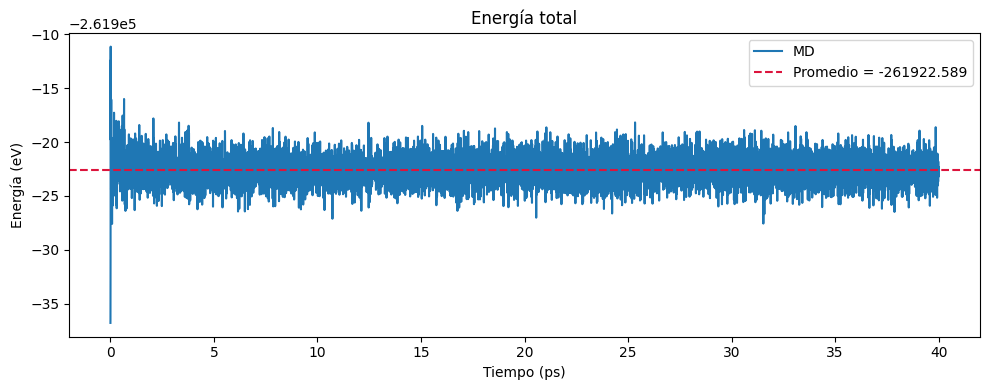

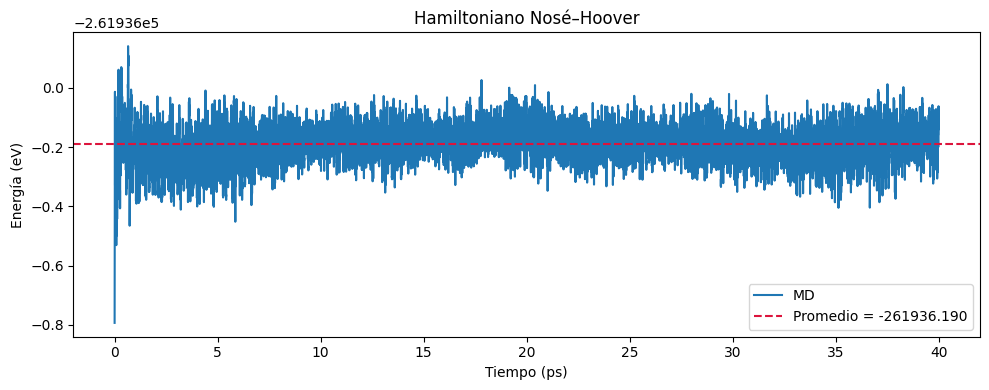

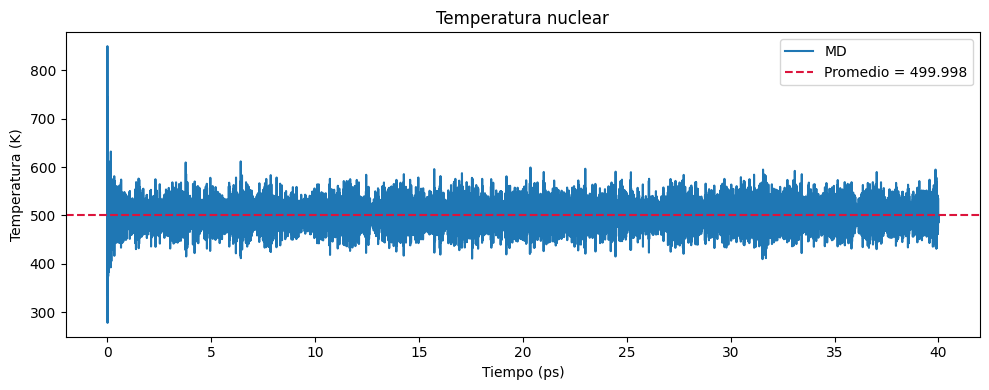

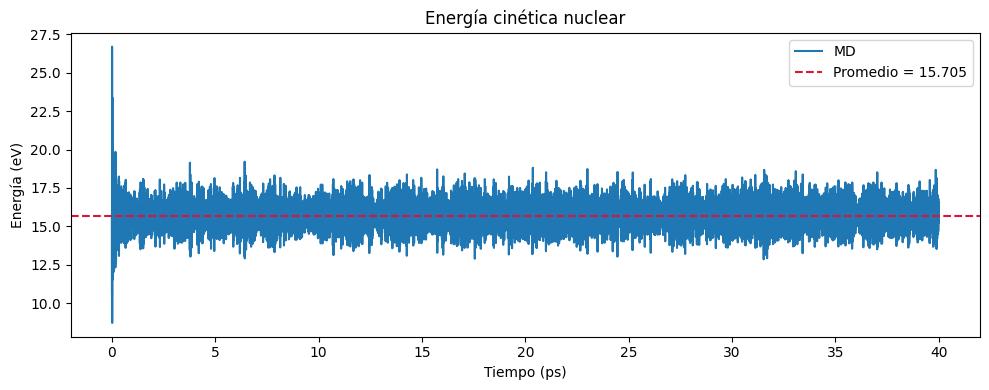

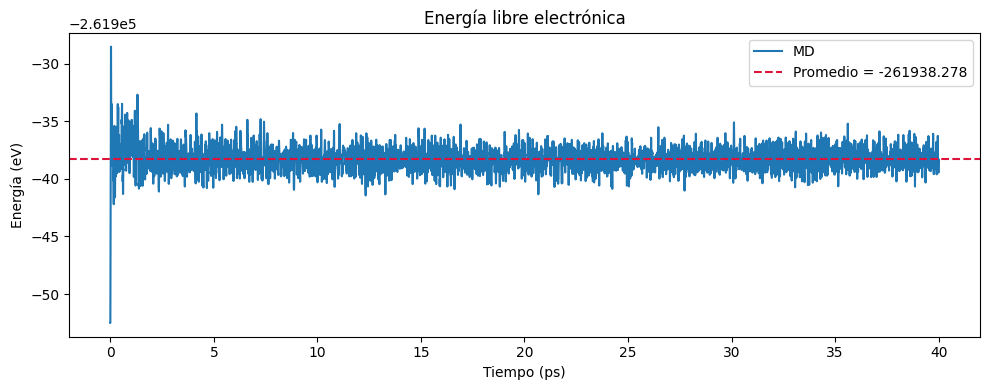

In [4]:
import re
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Archivo de entrada
# =========================
filename = "salida.out"

# =========================
# Contenedores
# =========================
step = []
time_ps = []
temp = []
ekin = []
efree = []
etot = []
nose = []

# =========================
# Expresiones regulares
# =========================
re_step  = re.compile(r"Time step number\s*:\s*(\d+)")
re_time  = re.compile(r"Simulation time\s*:\s*([Ee0-9\.\+\-]+)\s*ps")
re_temp  = re.compile(r"Temperature \(nuclei\)\s*:\s*([Ee0-9\.\+\-]+)\s*K")
re_ekin  = re.compile(r"Nuclear kinetic energy\s*:\s*([Ee0-9\.\+\-]+)\s*eV")
re_efree = re.compile(r"Electronic free energy\s*:\s*([Ee0-9\.\+\-]+)\s*eV")
re_etot  = re.compile(r"Total energy \(el\.\+nuc\.\)\s*:\s*([Ee0-9\.\+\-]+)\s*eV")
re_nose  = re.compile(r"Nose-Hoover Hamiltonian\s*:\s*([Ee0-9\.\+\-]+)\s*eV")

# =========================
# Lectura del archivo
# =========================
with open(filename, "r") as f:
    for line in f:
        if m := re_step.search(line):
            step.append(int(m.group(1)))
        elif m := re_time.search(line):
            time_ps.append(float(m.group(1)))
        elif m := re_temp.search(line):
            temp.append(float(m.group(1)))
        elif m := re_ekin.search(line):
            ekin.append(float(m.group(1)))
        elif m := re_efree.search(line):
            efree.append(float(m.group(1)))
        elif m := re_etot.search(line):
            etot.append(float(m.group(1)))
        elif m := re_nose.search(line):
            nose.append(float(m.group(1)))

# =========================
# Sincronización
# =========================
n = min(len(time_ps), len(etot))
time_ps = np.array(time_ps[:n])
temp    = np.array(temp[:n])
ekin    = np.array(ekin[:n])
efree   = np.array(efree[:n])
etot    = np.array(etot[:n])
nose    = np.array(nose[:n])

print(f"Pasos de MD analizados: {n}")

# =========================
# Promedios
# =========================
avg_temp  = temp.mean()
avg_ekin  = ekin.mean()
avg_efree = efree.mean()
avg_etot  = etot.mean()
avg_nose  = nose.mean()

print("\n--- PROMEDIOS ---")
print(f"Temperatura promedio        : {avg_temp:.2f} K")
print(f"Energía cinética promedio   : {avg_ekin:.6f} eV")
print(f"Energía libre electrónica   : {avg_efree:.6f} eV")
print(f"Energía total promedio      : {avg_etot:.6f} eV")
print(f"Hamiltoniano Nosé–Hoover    : {avg_nose:.6f} eV")

# =========================
# Gráficas
# =========================
def plot_with_avg(x, y, avg, xlabel, ylabel, title):
    plt.figure(figsize=(10, 4))
    plt.plot(x, y, label="MD")
    plt.axhline(avg, linestyle="--", color="crimson", label=f"Promedio = {avg:.3f}")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_with_avg(time_ps, etot, avg_etot,
              "Tiempo (ps)", "Energía (eV)", "Energía total")

plot_with_avg(time_ps, nose, avg_nose,
              "Tiempo (ps)", "Energía (eV)", "Hamiltoniano Nosé–Hoover")

plot_with_avg(time_ps, temp, avg_temp,
              "Tiempo (ps)", "Temperatura (K)", "Temperatura nuclear")

plot_with_avg(time_ps, ekin, avg_ekin,
              "Tiempo (ps)", "Energía (eV)", "Energía cinética nuclear")

plot_with_avg(time_ps, efree, avg_efree,
              "Tiempo (ps)", "Energía (eV)", "Energía libre electrónica")


Pasos de MD analizados: 20000

--- PROMEDIOS (Fase de producción) ---
Temperatura nuclear         : 500.00 ± 25.93 K
Energía cinética promedio   : 15.705053 eV
Energía libre electrónica   : -261938.323235 eV
Energía total promedio      : -261922.605281 ± 1.193442 eV
Hamiltoniano Nosé–Hoover    : -261936.183157 ± 0.055845 eV
Guardado: figuras/energía_total.png


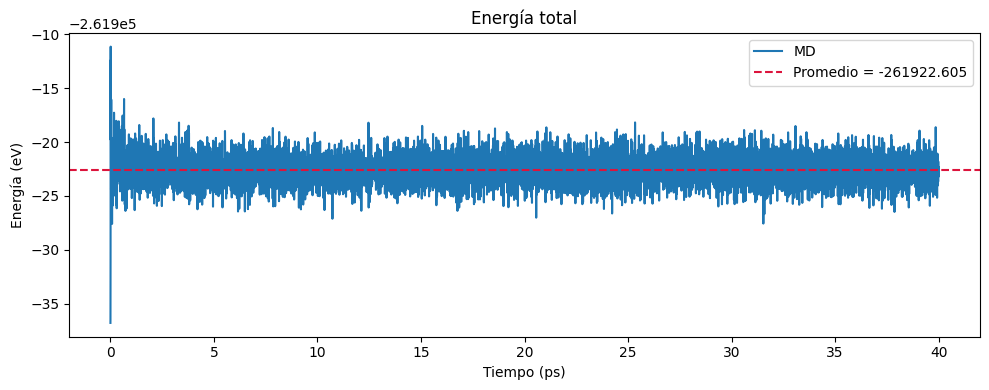

Guardado: figuras/hamiltoniano_noséhoover.png


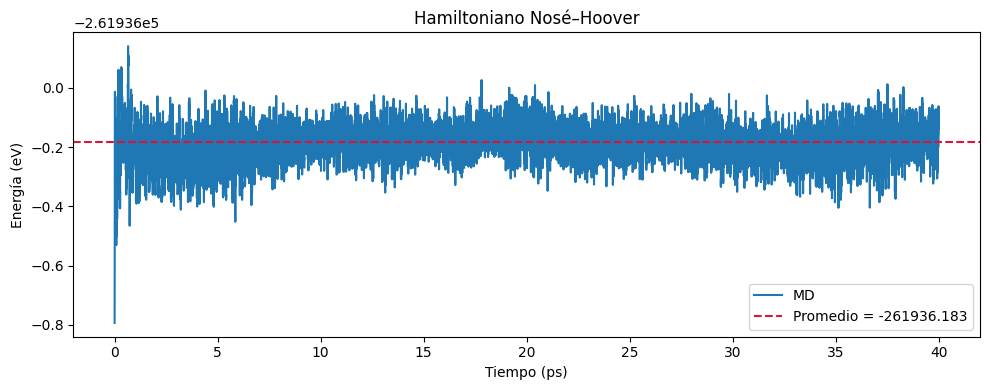

Guardado: figuras/temperatura_nuclear.png


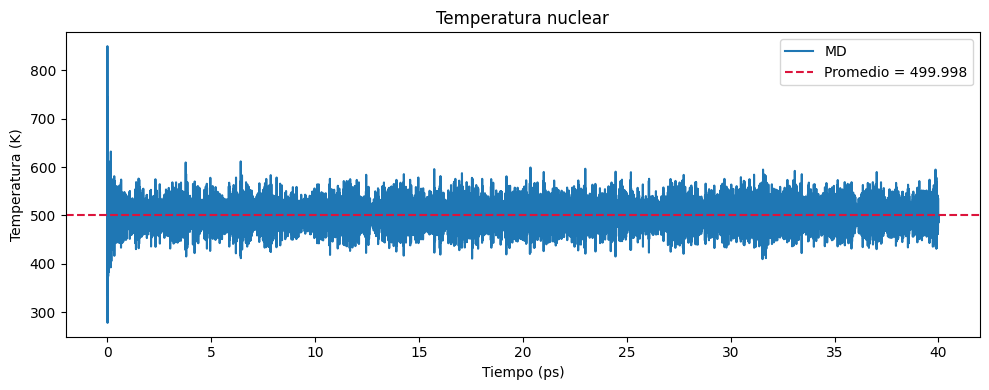

Guardado: figuras/energía_cinética_nuclear.png


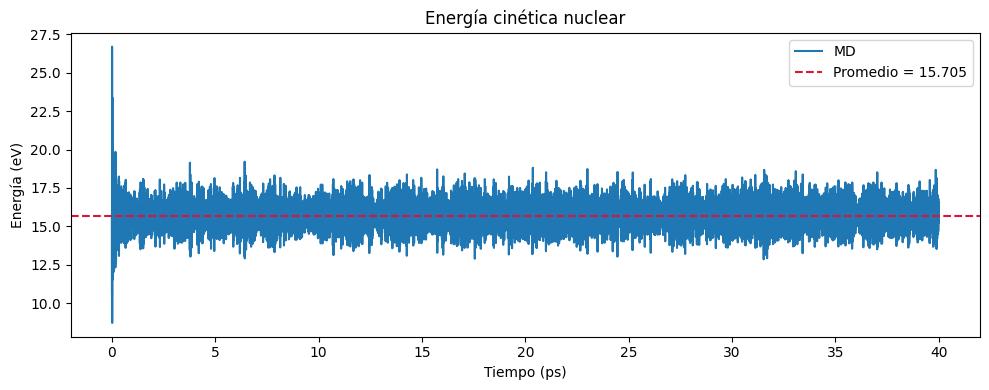

Guardado: figuras/energía_libre_electrónica.png


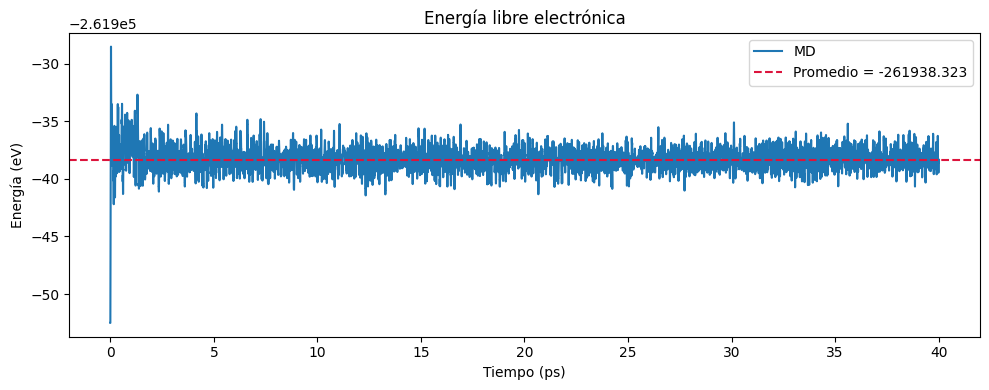

In [5]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Archivo de entrada
# =========================
filename = "salida.out"

# =========================
# Contenedores
# =========================
step = []
time_ps = []
temp = []
ekin = []
efree = []
etot = []
nose = []

# =========================
# Expresiones regulares
# =========================
re_step  = re.compile(r"Time step number\s*:\s*(\d+)")
re_time  = re.compile(r"Simulation time\s*:\s*([Ee0-9\.\+\-]+)\s*ps")
re_temp  = re.compile(r"Temperature \(nuclei\)\s*:\s*([Ee0-9\.\+\-]+)\s*K")
re_ekin  = re.compile(r"Nuclear kinetic energy\s*:\s*([Ee0-9\.\+\-]+)\s*eV")
re_efree = re.compile(r"Electronic free energy\s*:\s*([Ee0-9\.\+\-]+)\s*eV")
re_etot  = re.compile(r"Total energy \(el\.\+nuc\.\)\s*:\s*([Ee0-9\.\+\-]+)\s*eV")
re_nose  = re.compile(r"Nose-Hoover Hamiltonian\s*:\s*([Ee0-9\.\+\-]+)\s*eV")

# =========================
# Lectura del archivo
# =========================
with open(filename, "r") as f:
    for line in f:
        if m := re_step.search(line):
            step.append(int(m.group(1)))
        elif m := re_time.search(line):
            time_ps.append(float(m.group(1)))
        elif m := re_temp.search(line):
            temp.append(float(m.group(1)))
        elif m := re_ekin.search(line):
            ekin.append(float(m.group(1)))
        elif m := re_efree.search(line):
            efree.append(float(m.group(1)))
        elif m := re_etot.search(line):
            etot.append(float(m.group(1)))
        elif m := re_nose.search(line):
            nose.append(float(m.group(1)))

# =========================
# Sincronización
# =========================
n = min(len(time_ps), len(etot))
time_ps = np.array(time_ps[:n])
temp    = np.array(temp[:n])
ekin    = np.array(ekin[:n])
efree   = np.array(efree[:n])
etot    = np.array(etot[:n])
nose    = np.array(nose[:n])

print(f"Pasos de MD analizados: {n}")

# =========================
# Promedios y Desviaciones
# =========================
start_idx = int(n * 0.2) 


# start_idx = np.argmax(time_ps >= 2.0)

# Cálculos solo sobre la fase de producción
avg_temp  = temp[start_idx:].mean()
std_temp  = temp[start_idx:].std()

avg_ekin  = ekin[start_idx:].mean()
avg_efree = efree[start_idx:].mean()

avg_etot  = etot[start_idx:].mean()
std_etot  = etot[start_idx:].std()

avg_nose  = nose[start_idx:].mean()
std_nose  = nose[start_idx:].std()

print("\n--- PROMEDIOS (Fase de producción) ---")
print(f"Temperatura nuclear         : {avg_temp:.2f} ± {std_temp:.2f} K")
print(f"Energía cinética promedio   : {avg_ekin:.6f} eV")
print(f"Energía libre electrónica   : {avg_efree:.6f} eV")
print(f"Energía total promedio      : {avg_etot:.6f} ± {std_etot:.6f} eV")
print(f"Hamiltoniano Nosé–Hoover    : {avg_nose:.6f} ± {std_nose:.6f} eV")

# =========================
# Gráficas
# =========================
def plot_with_avg(x, y, avg, xlabel, ylabel, title, save_dir="figuras"):
    os.makedirs(save_dir, exist_ok=True)

    plt.figure(figsize=(10, 4))
    plt.plot(x, y, label="MD")
    plt.axhline(avg, linestyle="--", color="crimson", label=f"Promedio = {avg:.3f}")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    # Limpiar nombre de archivo
    filename = title.lower().replace(" ", "_").replace("–", "").replace("(", "").replace(")", "")
    filepath = os.path.join(save_dir, f"{filename}.png")

    # Guardar imagen
    plt.savefig(filepath, dpi=300)
    print(f"Guardado: {filepath}")

    plt.show()
plot_with_avg(time_ps, etot, avg_etot,
              "Tiempo (ps)", "Energía (eV)", "Energía total")

plot_with_avg(time_ps, nose, avg_nose,
              "Tiempo (ps)", "Energía (eV)", "Hamiltoniano Nosé–Hoover")

plot_with_avg(time_ps, temp, avg_temp,
              "Tiempo (ps)", "Temperatura (K)", "Temperatura nuclear")

plot_with_avg(time_ps, ekin, avg_ekin,
              "Tiempo (ps)", "Energía (eV)", "Energía cinética nuclear")

plot_with_avg(time_ps, efree, avg_efree,
              "Tiempo (ps)", "Energía (eV)", "Energía libre electrónica")


In [6]:
# ======================================================
# VERIFICACIÓN DE CONSERVACIÓN DEL HAMILTONIANO NH
# ======================================================

# -------- DATOS DEL SISTEMA --------
N_atoms = 243   

# -------- AJUSTE LINEAL H(t) = H0 + alpha * t --------
coeffs = np.polyfit(time_ps, nose, 1)
alpha = coeffs[0]     # eV / ps
H0    = coeffs[1]

alpha_per_atom = alpha / N_atoms * 1000.0  # meV / átomo / ps

# -------- ESTADÍSTICA --------
H_avg = nose.mean()
H_std = nose.std()
H_max = nose.max()
H_min = nose.min()

relative_range = (H_max - H_min) / abs(H_avg)

# -------- IMPRESIÓN DE RESULTADOS --------
print("\n================= VERIFICACIÓN NH =================")
print(f"Ajuste lineal: H(t) = H0 + α t")
print(f"α (deriva energética)        : {alpha:.3e} eV/ps")
print(f"α / N                        : {alpha_per_atom:.3f} meV/átomo/ps")
print(f"<H_NH>                       : {H_avg:.6e} eV")
print(f"σ(H_NH)                      : {H_std:.3e} eV")
print(f"(max-min)/|<H>|              : {relative_range:.3e}")

# -------- CRITERIOS DE CONVERGENCIA --------
ok_alpha = abs(alpha) < 1e-3
ok_alpha_atom = abs(alpha_per_atom) < 1.0
ok_stat = relative_range < 1e-4

print("\n--- DIAGNÓSTICO ---")

if ok_alpha and ok_alpha_atom and ok_stat:
    print("✅ Hamiltoniano de Nosé–Hoover CONSERVADO")
elif ok_alpha and ok_alpha_atom:
    print("⚠️  Hamiltoniano casi conservado")
else:
    print("❌ Hamiltoniano NO conservado")

print("===================================================")


================= VERIFICACIÓN NH =================
Ajuste lineal: H(t) = H0 + α t
α (deriva energética)        : 4.637e-04 eV/ps
α / N                        : 0.002 meV/átomo/ps
<H_NH>                       : -2.619362e+05 eV
σ(H_NH)                      : 6.387e-02 eV
(max-min)/|<H>|              : 3.565e-06

--- DIAGNÓSTICO ---
✅ Hamiltoniano de Nosé–Hoover CONSERVADO



=========== ANÁLISIS MD (RÉGIMEN ESTACIONARIO) ===========
Fracción descartada              : 0.20
Deriva NH (α)                    : -6.224e-04 eV/ps
Deriva NH / átomo                : -0.003 meV/átomo/ps
<H_NH>                           : -2.619362e+05 eV
σ(H_NH)                          : 5.584e-02 eV
(max−min)/|<H>|                  : 1.646e-06
✅ Hamiltoniano Nose–Hoover CONSERVADO


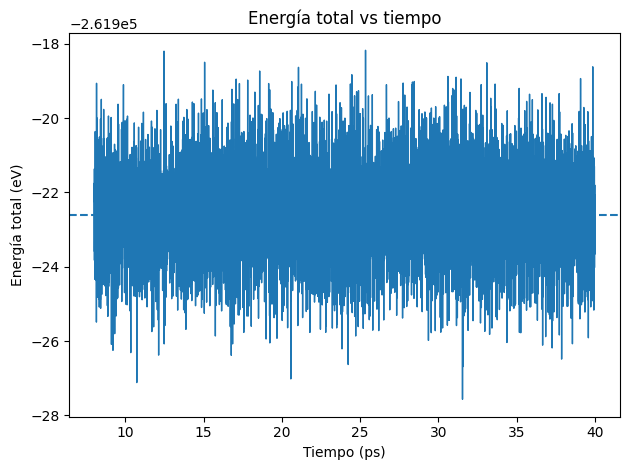

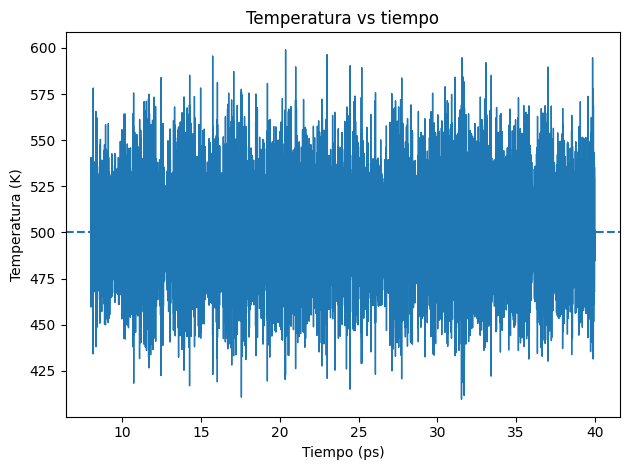

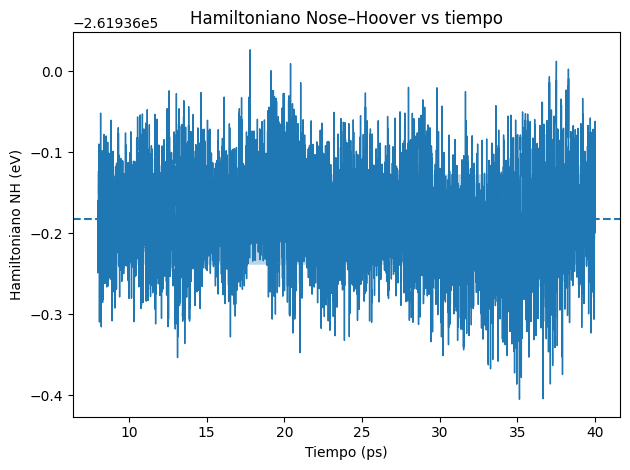


📁 Archivo exportado: MD_equilibrated_analysis.csv


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================================
# PARÁMETROS DE CONTROL
# ======================================================
N_atoms = 243        
discard_frac = 0.2  

# ======================================================
# ELIMINACIÓN AUTOMÁTICA DEL RÉGIMEN TRANSITORIO
# ======================================================
n_total = len(time_ps)
i0 = int(discard_frac * n_total)

t_eq = time_ps[i0:]
E_eq = etot[i0:]
T_eq = temp[i0:]
Ekin_eq = ekin[i0:]
H_eq = nose[i0:]

# ======================================================
# DERIVA ENERGÉTICA DEL HAMILTONIANO NH
# ======================================================
coeffs = np.polyfit(t_eq, H_eq, 1)
alpha = coeffs[0]  # eV/ps
alpha_atom = alpha / N_atoms * 1000.0  # meV/átomo/ps

# ======================================================
# ESTADÍSTICA
# ======================================================
def stats(x):
    return x.mean(), x.std(), x.min(), x.max()

E_avg, E_std, _, _ = stats(E_eq)
T_avg, T_std, _, _ = stats(T_eq)
K_avg, K_std, _, _ = stats(Ekin_eq)
H_avg, H_std, H_min, H_max = stats(H_eq)

rel_range = (H_max - H_min) / abs(H_avg)

# ======================================================
# DIAGNÓSTICO
# ======================================================
print("\n=========== ANÁLISIS MD (RÉGIMEN ESTACIONARIO) ===========")
print(f"Fracción descartada              : {discard_frac:.2f}")
print(f"Deriva NH (α)                    : {alpha:.3e} eV/ps")
print(f"Deriva NH / átomo                : {alpha_atom:.3f} meV/átomo/ps")
print(f"<H_NH>                           : {H_avg:.6e} eV")
print(f"σ(H_NH)                          : {H_std:.3e} eV")
print(f"(max−min)/|<H>|                  : {rel_range:.3e}")

if abs(alpha_atom) < 1.0 and rel_range < 1e-4:
    print("✅ Hamiltoniano Nose–Hoover CONSERVADO")
elif abs(alpha_atom) < 2.0:
    print("⚠️  Hamiltoniano casi conservado")
else:
    print("❌ Hamiltoniano NO conservado")

# ======================================================
# GRÁFICAS CON BARRAS DE DESVIACIÓN
# ======================================================
def plot_with_stats(t, y, avg, std, ylabel, title):
    plt.figure()
    plt.plot(t, y, lw=1)
    plt.axhline(avg, ls="--")
    plt.fill_between(t, avg - std, avg + std, alpha=0.3)
    plt.xlabel("Tiempo (ps)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()

plot_with_stats(t_eq, E_eq, E_avg, E_std, "Energía total (eV)",
                "Energía total vs tiempo")
plot_with_stats(t_eq, T_eq, T_avg, T_std, "Temperatura (K)",
                "Temperatura vs tiempo")
plot_with_stats(t_eq, H_eq, H_avg, H_std, "Hamiltoniano NH (eV)",
                "Hamiltoniano Nose–Hoover vs tiempo")

plt.show()

# ======================================================
# EXPORTACIÓN A CSV
# ======================================================
df = pd.DataFrame({
    "time_ps": t_eq,
    "energy_eV": E_eq,
    "temperature_K": T_eq,
    "ekin_eV": Ekin_eq,
    "nose_hoover_eV": H_eq
})

df.to_csv("MD_equilibrated_analysis.csv", index=False)

print("\n📁 Archivo exportado: MD_equilibrated_analysis.csv")

In [8]:
print(globals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', 're', 'plt', 'filename', 'step', 'time_ps', 'temp', 'ekin', 'efree', 'etot', 'nose', 're_step', 're_time', 're_temp', 're_ekin', 're_efree', 're_etot', 're_nose', 'f', 'line', 'm', 'n', '_i2', 'np', 'avg_temp', 'avg_ekin', 'avg_efree', 'avg_etot', 'avg_nose', 'plot_with_avg', '_i3', '_i4', '_i5', 'os', 'start_idx', 'std_temp', 'std_etot', 'std_nose', '_i6', 'N_atoms', 'coeffs', 'alpha', 'H0', 'alpha_per_atom', 'H_avg', 'H_std', 'H_max', 'H_min', 'relative_range', 'ok_alpha', 'ok_alpha_atom', 'ok_stat', '_i7', 'pd', 'discard_frac', 'n_total', 'i0', 't_eq', 'E_eq', 'T_eq', 'Ekin_eq', 'H_eq', 'alpha_atom', 'stats', 'E_avg', 'E_std', 'T_avg', 'T_std', 'K_avg', 'K_std', 'rel_range', 'plot_with_stats', 'df', '_i8'])
